---
title: US Market Trends Analysis
# subtitle: A Comprehensive Guide to Analyzing the S&P 500 Index Using Python
author: Samantha Pang
date: 2025-12-01
date-modified: last-modified 
format: 
    html: 
        toc: true
        code-fold: true
---


## Prerequisites!
Libraries needed for this exercise: `yfinance`, `matplotlib`, `numpy`, `seaborn`.

`yfinance` is a Python library that allows you to download historical market data from Yahoo Finance. It is widely used for fetching stock prices (open, close, high, low), dividends, splits, and other financial data.

## Objective
This project aims to understand leading indicators of the U.S. stock market by analyzing the S&P 500,  Dow Jones, and NASDAQ indices. We will explore historical data, visualize trends, and identify patterns that helps investors make well-informed decisions.

## Leading Indicators
### S&P 500 
The S&P 500 (Standard & Poor's 500) is a stock market index that measures the performance of 500 large companies listed on U.S. stock exchanges. It is one of the most commonly followed equity indices and is often considered a benchmark for the overall health of the US stock market.

### Dow Jones
The Dow Jones Industrial Average (DJIA) is a stock market index that measures the stock performance of 30 large, publicly owned companies based in the U.S. It is one of the oldest and most widely recognized stock market indices in the world. 

### NASDAQ
The NASDAQ Composite is a stock market index that includes almost all stocks listed on the NASDAQ stock exchange. It is heavily weighted towards technology companies and is often used as a benchmark for the performance of the tech sector.

## Overall time Series Trends
Line graph below shows the overall upward trends of the S&P 500, Dow Jones, and NASDAQ indices over the past 30 years. The Dow Jones exhibits the highest growth, followed by NASDAQ comes second and then S&P 500. The Dow Jones and NASDAQ display greater volatility compared to the S&P 500, which follows a steadier growth trajectory.

[*********************100%***********************]  3 of 3 completed


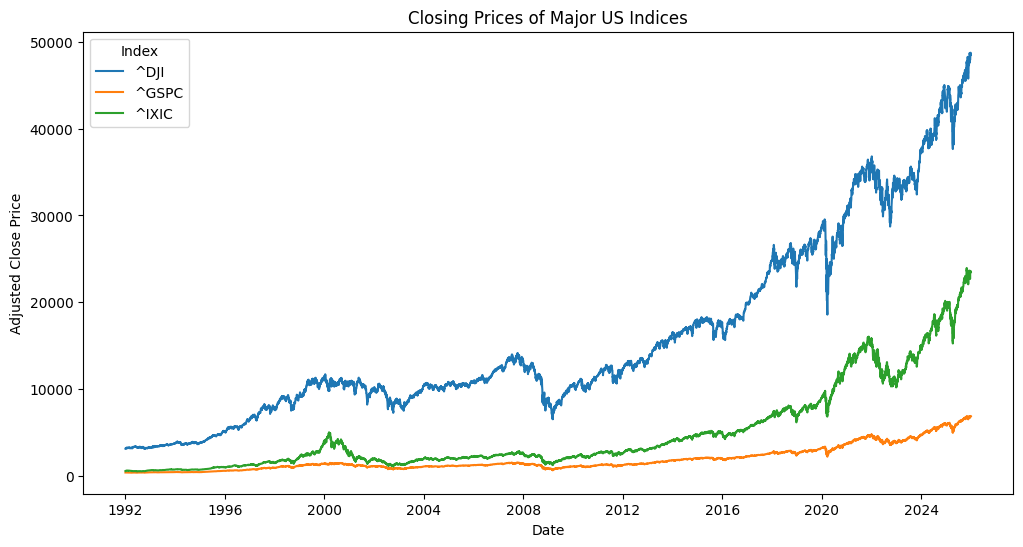

In [1]:
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

startdate = "1990-01-01"
enddate = "2025-12-31"
tickers = ["^GSPC", "^DJI", "^IXIC"]

# auto_adjust=True to get adjusted close prices (accounting for dividends and stock splits)
df = yf.download(
    tickers,
    start=startdate,
    end=enddate,
    auto_adjust=True
)["Close"]

sp500, dw30, nasdaq = df["^GSPC"], df["^DJI"], df["^IXIC"]

# today/yesterday price ratio / gross return
def returns(prices):
    return np.log(prices/prices.shift(1)).dropna()

sp500ret, dw30ret, nasdaqret = returns(sp500), returns(dw30), returns(nasdaq)

data = df.dropna().reset_index().melt(
    id_vars="Date", var_name="Index", value_name="Close")
plt.figure(figsize=(12, 6))
sns.lineplot(data=data, x="Date", y="Close", hue="Index")
plt.title("Closing Prices of Major US Indices")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.show()


## Histogram Analysis
### Raw Closing Prices
Visualizing the closing prices using histograms, we see right skewed distributions, indicating that there are more days with lower closing prices and fewer days with very high closing prices. One reason for the sparse distribution is that closing prices have increased continuously over the years, resulting in a wide range of data points. 

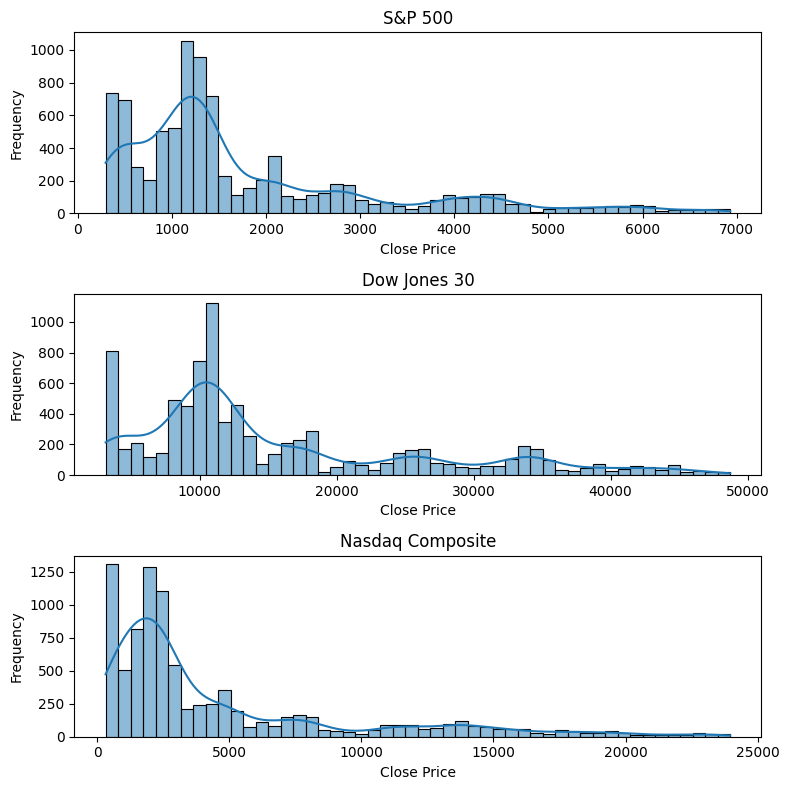

In [2]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8))
series_list = [sp500, dw30, nasdaq]

for series, name, i in zip(series_list, ["S&P 500", "Dow Jones 30", "Nasdaq Composite"], range(3)):
    sns.histplot(series, kde=True, bins=50, ax=axes[i])
    axes[i].set_title(name)
    for ax in axes:
        ax.set_xlabel("Close Price")
        ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Log Trasformed Returns

With log transformation, we observe more normalized distributions. Log returns convert multiplicative processes into additive ones, making the data easier to analyze statistically. 

Histograms show more symmetric distributions of the logarithm returns of all 3 of the indices over the last 30 years, providing insight into their performance and volatility. The majority of returns clustering around the mean indicates smaller price movements. The probability of extreme returns (both positive and negative) is low, suggesting a limited risk of significant gains or losses during this period. Overall, the histograms suggest that all 3 indices has relatively stable performance with moderate volatility over the year, making them suitable for long-term investment strategies.

S&P 500 's Total Return Over Past 30 Years:  18.2029
S&P 500 's Annual Volatility:  0.1807
Dow Jones 30 's Total Return Over Past 30 Years:  14.2882
Dow Jones 30 's Annual Volatility:  0.1743
Nasdaq Composite 's Total Return Over Past 30 Years:  50.1083
Nasdaq Composite 's Annual Volatility:  0.2313


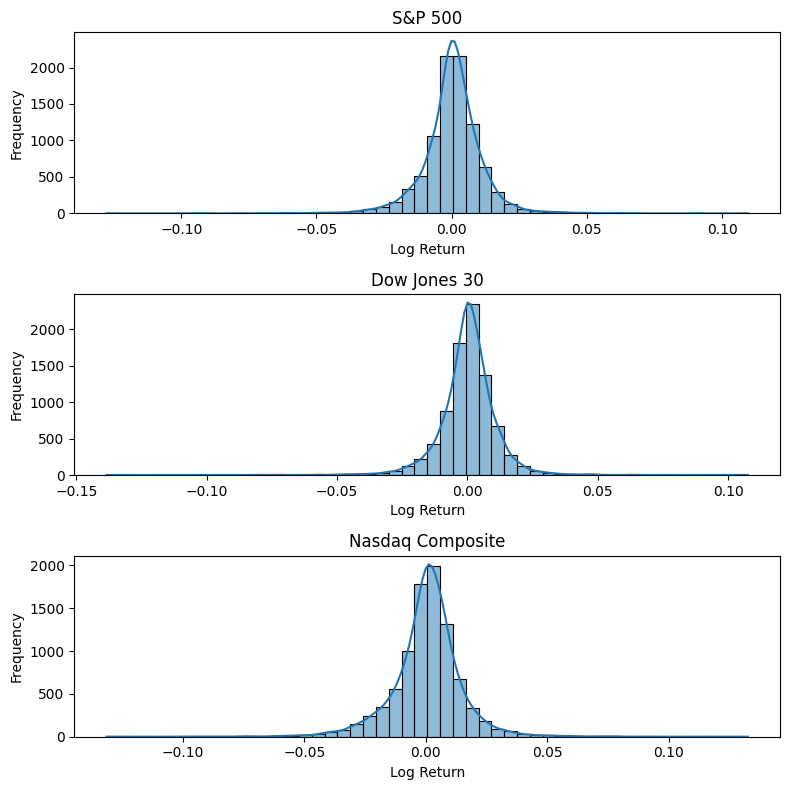

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(8, 8))
series_list = [sp500ret, dw30ret, nasdaqret]

for series, name, i in zip(series_list, ["S&P 500", "Dow Jones 30", "Nasdaq Composite"], range(3)):
    sns.histplot(series, kde=True, bins=50, ax=axes[i])
    axes[i].set_title(name)
    for ax in axes:
        ax.set_xlabel("Log Return")
        ax.set_ylabel("Frequency")
    print(name, "'s Total Return Over Past 30 Years: ",(np.exp(series.sum())-1).round(4))
    print(name, "'s Annual Volatility: ", (series.std()*np.sqrt(252)).round(4)) 

plt.tight_layout()
plt.show()

## Total Returns and Annual Volatility

The total returns of 3 indices show significant growth. NASDAQ has the highest return and volatility, 50.27/ 23%, i.e. $1 invested in NASDAQ would have grown to $50.27 over the past 30 years, with annual fluctuations of 23%. In contrast, the Dow Jones has the lowest returns and volatility, while S&P 500 showing a more stable performance compared to NASDAQ.

## Statistical Measures of Log Returns
### Mean, Median, Skewness, Kurtosis
The distributions of the log returns of all 3 indices has a symmetric distribution, but we can also use statistical measures to confirm whether they follow a normal distribution. Let's find mean, median, skewness, kurtosis of log return for each index. 

In [4]:
for series, name in zip(series_list, ["S&P 500", "Dow Jones 30", "Nasdaq Composite"]):
    print(name, "'s mean, median, mode: ",series.mean().round(4), "/",series.median().round(4),"/", series.mode().round(4))
    print(name, "'s skewness, kurtosis: ", series.skew().round(4),"/", series.kurt().round(4)) 

S&P 500 's mean, median, mode:  0.0003 / 0.0006 / 0    0.0
Name: ^GSPC, dtype: float64
S&P 500 's skewness, kurtosis:  -0.3651 / 10.883
Dow Jones 30 's mean, median, mode:  0.0003 / 0.0006 / 0    0.0
Name: ^DJI, dtype: float64
Dow Jones 30 's skewness, kurtosis:  -0.3851 / 13.0153
Nasdaq Composite 's mean, median, mode:  0.0004 / 0.0011 / 0    0.0
Name: ^IXIC, dtype: float64
Nasdaq Composite 's skewness, kurtosis:  -0.1797 / 6.8763


The means, medians, and mode of the indices are extremely close to each other, indicating that the distributions are indeed symmetric and centered around the same value. Skewness explains whether a distribution is left or right leaning; in this case, a minimal left leaning is observed. Kurtosis measures the "tailedness" of the distributions. The high kurtosis values indicates extreme price movements happen frequently.

### Standard Deviation and Z-Score

For a normal distribution, about 68% of the data falls within one standard deviation of the mean, about 95% falls within two standard deviations, and about 99.7% falls within three standard deviations. This is known as the empirical rule or the 68-95-99.7 rule.

    μ ± 1σ → 0.68
    μ ± 2σ → 0.95
    μ ± 3σ → 0.997

Z-Score is great for identifying outliers in a dataset. A z-score indicates how many standard deviations a data point is from the mean. Typically, a z-score above 3 or below -3 is considered an outlier.

    z=(x−μ)/σ

    |z| < 1 → normal movements
    |z| ≥ 1 → elevated volatility
    |z| ≥ 2 → unusually volatile
    |z| ≥ 3 → crash / spike territory

In [25]:
for series, name in zip(series_list, ["S&P 500", "Dow Jones 30", "Nasdaq Composite"]):
    # count the number of observations within 1, 2, and 3 standard deviations from the mean
    # mu-sigma to mu+sigma
    print(name, "'s 1,2,3 std away from mean: ",((series >= series.mean()- series.std()) & (series <= series.mean()+series.std())).mean().round(4)
        ,((series >= series.mean()-2* series.std()) & (series <= series.mean()+2*series.std())).mean().round(4)
        ,((series >= series.mean()- 3*series.std()) & (series <= series.mean()+3*series.std())).mean().round(4))
    print(name, "'s mean and median z-score: ", abs((series- series.mean())/series.std()).mean().round(4), abs((series- series.mean())/series.std()).median().round(4))

S&P 500 's 1,2,3 std away from mean:  0.7906 0.9512 0.9844
S&P 500 's mean and median z-score:  0.6655 0.4491
Dow Jones 30 's 1,2,3 std away from mean:  0.7913 0.9542 0.9857
Dow Jones 30 's mean and median z-score:  0.6638 0.453
Nasdaq Composite 's 1,2,3 std away from mean:  0.7836 0.9466 0.9848
Nasdaq Composite 's mean and median z-score:  0.6798 0.4594


Looking at the probabiles of observations within 1, 2, and 3 standard deviations from the mean for all 3 indices, we can see that they have a high percentage of observations within 1 standard deviation (around 78-79%), with normal distibution for 2 and 3 standard deviations. This suggests that leptokurtic distribution. Majority of the data points have low changes in returns, with a few extreme values causing the higher kurtosis.
Using Z-score, we can once again confirm that majority of the days fall within normal movements, as mean and median z-scores are less than 1 for all 3 indices. 

## Conclusion
All 3 indices show relatively stable performance with moderate volatility over time. The S&P 500 and Dow Jones indices demonstrate more stable performance compared to NASDAQ. NASDAQ has the highest return and volatility, making it suitable for investors who can tolerate higher risk in exchange for potentially higher rewards. 

The distributions of log returns for all 3 indices are symmetric, but the high kurtosis values indicate frequent extreme movements. A friendly advice for investors is to consider long-term investment strategies and be prepared for periods of market volatility. High returns come from surviving drawdowns rather than timing the market.